![](Images/banner_health_analytics.png){fig-align="center" width="100%"}



### Module 07: Spatial Epidemiology


# Spatial Autocorrelation 


***
**Learning objectives**
- Understand spatial autocorrelation: Tobler's First Law of Geography
- Build spatial weights matrices (queen contiguity, rook, distance-based, k-NN)
- Compute Global Moran's I and its significance via permutation
- Calculate Local Moran's I (LISA) to identify spatial clusters
- Produce cluster maps: High-High, Low-Low, High-Low, Low-High quadrants
- Interpret Moran scatterplots for health outcomes

**Estimated time:** 3 hours | **Level:** Advanced  
**Libraries:** `numpy`, `scipy`, `matplotlib`, `pysal` (optional)


## 1. Setup & Dataset

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, warnings
from pyproj import Transformer
warnings.filterwarnings("ignore"); import os; os.makedirs("/tmp/mod07", exist_ok=True)
plt.rcParams.update({"figure.dpi":120,"figure.facecolor":"white",
                     "axes.spines.top":False,"axes.spines.right":False})

# County Health Rankings + CDC diabetes prevalence (CONUS + DC)
raw = pd.read_csv("Data/usa_data.csv")

# Centroids stored as NAD83 Albers metres (EPSG:5070) — convert to WGS84 lon/lat
to_wgs84 = Transformer.from_crs(5070, 4326, always_xy=True)
lon, lat = to_wgs84.transform(raw.centroid_x_m.values, raw.centroid_y_m.values)

df = pd.DataFrame({
    "county_id": raw.fips.astype(str).str.zfill(5),
    "fips": raw.fips.astype(int),
    "county": raw.county, "state_abbr": raw.state_abbr, "state_name": raw.state_name,
    "lon": lon, "lat": lat,
    "x_m": raw.centroid_x_m, "y_m": raw.centroid_y_m,
    "diabetes_prev": raw.y_diabetes_prevalence_adults_with_diabetes,
    "pct_65plus": raw.chr_65_and_older_65_and_over,
    "pct_exercise": raw.chr_access_to_exercise_opportunities,
    "pct_obesity": raw.chr_adult_obesity,
    "food_env_index": raw.chr_food_environment_index,
    "n_pcp": raw.chr_primary_care_physicians,
    "rural_pop": raw.chr_rural,
    "n_unemployed": raw.chr_unemployment,
    "n_uninsured": raw.chr_uninsured,
})

# Standardised prevalence ratio: county rate / national mean (SMR analogue)
df["smr"] = df.diabetes_prev / df.diabetes_prev.replace(0, np.nan).mean()
# Rename 
df.rename(columns={"diabetes_prev": "Diabetes"}, inplace=True)
df.rename(columns={"pct_obesity": "Obesity"}, inplace=True)
df.rename(columns={"pct_65plus": "Population 65+"}, inplace=True)
df.rename(columns={"food_env_index": "Food env. index"}, inplace=True)
df.rename(columns={"n_pcp": "PCP"}, inplace=True)
df.rename(columns={"n_unemployed": "Unemployed"}, inplace=True)
df.rename(columns={"n_uninsured": "Uninsured"}, inplace=True)

N_COUNTIES = len(df)
print(f"County dataset: N={N_COUNTIES} | Diabetes: {df['Diabetes'].mean():.1f}% (SD={df['Diabetes'].std():.1f})")
print(f"Obesity: {df['Obesity'].mean():.1f}% | 65+: {df['Population 65+'].mean():.1f}% | Food env. index: {df['Food env. index'].mean():.1f}")

# Join df with @Data/US_COUNTY.shp to create a spatial GeoDataFrame
try:
    import geopandas as gpd
    from shapely.geometry import Point
    print(f"geopandas {gpd.__version__} available")
    GEOPANDAS_OK = True
except ImportError:
    print("geopandas or shapely not found. Please install with: pip install geopandas shapely")
    GEOPANDAS_OK = False

if GEOPANDAS_OK:
    # Load the US county shapefile
    county_shapes = gpd.read_file("Data/US_COUNTY.shp")
    county_shapes["FIPS"] = county_shapes["FIPS"].astype(int)
    # Update Shannon County SD (46113) to Oglala Lakota (46102)
    county_shapes["FIPS"] = county_shapes["FIPS"].replace({46113: 46102})
    # Join df (tabular health data) with the county shapefile using FIPS
    gdf = county_shapes.merge(df, left_on="FIPS", right_on="fips", how="inner")
    print(f"GeoDataFrame loaded: {len(gdf)} counties")
    print(f"CRS: {gdf.crs}")
    print(f"Bounding box (Albers meters): {np.round(gdf.total_bounds, 0)}")
else:
    print("geopandas not available; spatial DataFrame could not be created.")

County dataset: N=3108 | Diabetes: 10.5% (SD=2.2)
Obesity: 36.2% | 65+: 20.1% | Food env. index: 7.4
geopandas 1.1.2 available


GeoDataFrame loaded: 3108 counties
CRS: PROJCS["NAD_1983_Albers",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Albers_Conic_Equal_Area"],PARAMETER["latitude_of_center",23],PARAMETER["longitude_of_center",-96],PARAMETER["standard_parallel_1",29.5],PARAMETER["standard_parallel_2",45.5],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Bounding box (Albers meters): [-2356114.   268091.  2258200.  3172568.]


## 2. Spatial Weights Matrix

A **spatial weights matrix W** encodes the neighbourhood structure:
- **Queen contiguity**: shares any boundary point or corner
- **Rook contiguity**: shares an edge only
- **Distance-based**: w_ij = 1 if distance < threshold
- **k-NN**: each unit connected to its k nearest neighbours
- **Inverse distance**: w_ij = 1/d_ij (continuous)

Row-standardisation: W* where each row sums to 1 (so W*x = spatial lag of x)


In [2]:
# Update: Build spatial weights based on actual county spatial adjacency and geometry using gdf

import libpysal
from libpysal.weights import Queen, KNN, DistanceBand

# Use the centroids for distance and knn-based weights
gdf_centroids = gdf.geometry.centroid
coords = np.column_stack((gdf_centroids.x.values, gdf_centroids.y.values))

# Queen contiguity weights (polygon-based)
w_queen = Queen.from_dataframe(gdf)
W_queen = w_queen.full()[0].astype(float)
# Row-standardize
row_sums = W_queen.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
W_queen = W_queen / row_sums

# K-nearest neighbors
k = 6
w_knn = KNN.from_dataframe(gdf, k=k)
W_knn = w_knn.full()[0].astype(float)
row_sums = W_knn.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
W_knn = W_knn / row_sums

# Fixed distance band (threshold=90th percentile nearest neighbor * 2, similar to above)
thresh = np.percentile(libpysal.cg.kdtree.KDTree(coords).query(coords, k=2)[0][:,1], 90) * 2
w_dist = DistanceBand.from_dataframe(gdf, threshold=thresh, binary=True, silence_warnings=True)
W_dist = w_dist.full()[0].astype(float)
row_sums = W_dist.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
W_dist = W_dist / row_sums

N = len(gdf)

print(f"Queen W: {N}x{N} | Mean neighbours: {(W_queen>0).sum(axis=1).mean():.1f}")
print(f"KNN W  : {N}x{N} | Mean neighbours: {(W_knn>0).sum(axis=1).mean():.1f}")
print(f"Dist W : {N}x{N} | Mean neighbours: {(W_dist>0).sum(axis=1).mean():.1f}")


Queen W: 3108x3108 | Mean neighbours: 5.8
KNN W  : 3108x3108 | Mean neighbours: 6.0
Dist W : 3108x3108 | Mean neighbours: 20.4


## 3. Global Moran's I

### What is Global Moran's I? (Math for Dummies)

Global Moran's I is a single number that tells you whether places on a map with high (or low) values are clustered together, or scattered randomly.

#### Math intuition (for dummies!):
- Imagine you have values for every county, like the heart disease rate.
- For each county, look at its value and the values of its neighbours (using a 'weights matrix' W).
- Moran's I compares:
  - Are high values near other high values, and low near low? (clustering, Moran's I > 0)
  - Are high and low values mixed up? (random, Moran's I ≈ 0)
  - Are high values near low, and vice versa? (checkerboard, Moran's I < 0)

**The "for dummies" math:**

1. First, for each county, subtract the average rate from its value. This gives you "how much above or below average is this county?" Call this z.
2. Do the same for all counties so you have a list of z's.
3. Look up the neighbours for each county (using W), and see if a county’s z is similar to its neighbours’ z's.
4. Moran's I formula looks like:

 $$
 I = \frac{N}{\sum W} \times \frac{\sum_i z_i \left( \sum_j W_{ij} z_j \right)}{\sum_i z_i^2}
 $$

   - **N**: Number of counties
   - **W**: The matrix showing who's neighbours with whom
   - **z**: Values after subtracting the mean

- If "like is near like" a lot, I is positive and big.
- If there’s no pattern, I is close to zero.
- If opposites are neighbours, I is negative.

**In short:** Moran's I = "Do neighbours tend to be similar, or not?"

In [3]:
def morans_i(y, W, n_perm=999, seed=42):
    """
    Compute Global Moran's I with permutation inference.
    I = (N / sum(W)) * (z'Wz) / (z'z)
    where z = y - mean(y)
    """
    n = len(y)
    z = y - y.mean()
    S0 = W.sum()
    Wz = W @ z
    I_obs = (n / S0) * (z @ Wz) / (z @ z)
    # Permutation test
    rng = np.random.default_rng(seed)
    I_perm = np.zeros(n_perm)
    for b in range(n_perm):
        z_perm = rng.permutation(z)
        Wz_p = W @ z_perm
        I_perm[b] = (n / S0) * (z_perm @ Wz_p) / (z_perm @ z_perm)
    p_value = (np.abs(I_perm) >= np.abs(I_obs)).mean()
    e_i = -1 / (n - 1)
    return {"I":I_obs, "E[I]":e_i, "p_value":p_value,
            "I_perm":I_perm, "z_score":(I_obs-e_i)/I_perm.std()}

# Use existing gdf's variables directly by referencing columns
print("Global Moran's I Results:\n")
print(f"{'Variable':20s} {'Moran I':>10s} {'E[I]':>8s} {'z-score':>10s} {'p-value':>10s}")
print("-"*62)

# List of variable names (keys from gdf you wish to analyze)
var_specs = [
    ("Diabetes (%)", "Diabetes"),
    ("Obesity (%)", "Obesity"),
    ("Population 65+", "Population 65+"),
    ("Food env. index", "Food env. index"),
    ("PCP per 10k", "PCP"),
    ("Uninsured (%)", "Uninsured"),
    ("SMR", "smr"),
]

# Collect variables from gdf, guard against missing columns
variables = []
for var_label, col in var_specs:
    col_name = None
    # Handle exact match
    if col in gdf.columns:
        col_name = col
    # Also allow for accidental trailing space *once* for compatibility
    elif f"{col} " in gdf.columns:
        col_name = f"{col} "
    else:
        raise KeyError(f"Column '{col}' not found in gdf. Available columns: {list(gdf.columns)}")
    variables.append((var_label, gdf[col_name]))

for var_name, values in variables:
    res = morans_i(values.values, W_queen)
    sig = "***" if res["p_value"]<0.001 else "**" if res["p_value"]<0.01 else "*" if res["p_value"]<0.05 else ""
    print(f"  {var_name:18s} {res['I']:>10.4f} {res['E[I]']:>8.4f} {res['z_score']:>10.2f} {res['p_value']:>8.4f} {sig}")

# Moran I for CVD rate (main analysis)
res_diabetes = morans_i(gdf["Diabetes"].values, W_queen)


Global Moran's I Results:

Variable                Moran I     E[I]    z-score    p-value
--------------------------------------------------------------


  Diabetes (%)           0.6650  -0.0003      61.64   0.0000 ***


  Obesity (%)            0.6255  -0.0003      59.68   0.0000 ***


  Population 65+         0.3790  -0.0003      35.15   0.0000 ***


  Food env. index        0.3389  -0.0003      31.28   0.0000 ***


  PCP per 10k            0.3646  -0.0003      34.54   0.0000 ***


  Uninsured (%)          0.2495  -0.0003      23.41   0.0000 ***


  SMR                    0.6650  -0.0003      61.64   0.0000 ***



The Global Moran's I statistic quantifies the overall spatial autocorrelation of the variable (e.g., CVD rate) across the study area.  
- A **positive** and significant Moran's I (with p-value < 0.05) indicates that areas with high (or low) values cluster together—there is spatial clustering of similar values (either hot spots or cold spots).
- A **negative** Moran's I suggests spatial dispersion—neighboring areas tend to have dissimilar values.
- A value near zero (and a non-significant p-value) indicates a random spatial pattern, with no evidence of spatial autocorrelation.

In the results above, several variables—such as Diabetes (%), Obesity (%), Population 65+, Food environment index, PCP per 10k, Uninsured (%), and SMR—show a positive and statistically significant Moran's I. This indicates strong spatial clustering; counties with high values for these health or resource indicators tend to be near other counties with similarly high values, and the same holds for counties with low values.

The high z-scores and low permutation p-values (** or ***) for many variables confirm that the observed spatial clustering is unlikely to be due to random chance. These findings provide robust evidence for spatial autocorrelation in these county-level health and resource measures.

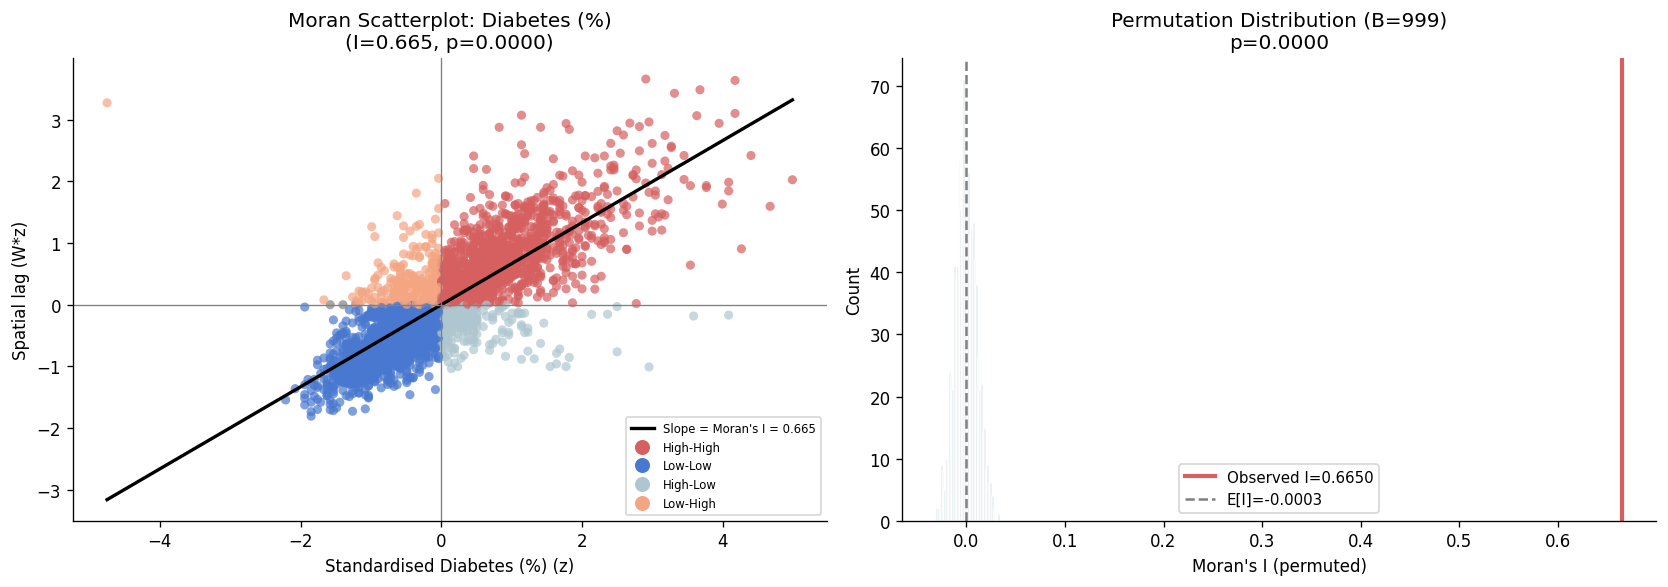

In [4]:
# Moran scatterplot for Diabetes (%) variable from gdf
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Moran scatterplot: Diabetes (%) vs spatial lag (W*y)
z_diabetes = (gdf["Diabetes"] - gdf["Diabetes"].mean()) / gdf["Diabetes"].std()
Wz_diabetes = W_queen @ z_diabetes
quadrant = ((z_diabetes > 0) & (Wz_diabetes > 0)).astype(int)*1 + \
           ((z_diabetes < 0) & (Wz_diabetes < 0)).astype(int)*2 + \
           ((z_diabetes > 0) & (Wz_diabetes < 0)).astype(int)*3 + \
           ((z_diabetes < 0) & (Wz_diabetes > 0)).astype(int)*4

quad_colors = {1:"#D65F5F",2:"#4878CF",3:"#AEC6CF",4:"#F4A582"}
quad_labels = {1:"High-High",2:"Low-Low",3:"High-Low",4:"Low-High"}
colors_moran = [quad_colors.get(q,"gray") for q in quadrant]

axes[0].scatter(z_diabetes, Wz_diabetes, c=colors_moran, alpha=0.7, s=30, edgecolors="none")
m_slope = np.polyfit(z_diabetes, Wz_diabetes, 1)[0]
xl = np.linspace(z_diabetes.min(), z_diabetes.max(), 100)
axes[0].plot(xl, m_slope*xl, "k-", lw=2, label=f"Slope = Moran's I = {res_diabetes['I']:.3f}")
axes[0].axhline(0, color="gray", lw=0.8); axes[0].axvline(0, color="gray", lw=0.8)
axes[0].set_xlabel("Standardised Diabetes (%) (z)"); axes[0].set_ylabel("Spatial lag (W*z)")
axes[0].set_title(f"Moran Scatterplot: Diabetes (%)\n(I={res_diabetes['I']:.3f}, p={res_diabetes['p_value']:.4f})")
axes[0].legend(fontsize=8)
for q in [1,2,3,4]:
    axes[0].plot([],[],"o",color=quad_colors[q],label=quad_labels[q],ms=8)
axes[0].legend(fontsize=7)

# Permutation distribution for Diabetes (%)
axes[1].hist(res_diabetes["I_perm"], bins=40, color="#AEC6CF", edgecolor="white", alpha=0.9)
axes[1].axvline(res_diabetes["I"], color="#D65F5F", lw=2.5, label=f"Observed I={res_diabetes['I']:.4f}")
axes[1].axvline(res_diabetes["E[I]"], color="gray", ls="--", lw=1.5, label=f"E[I]={res_diabetes['E[I]']:.4f}")
axes[1].set_xlabel("Moran's I (permuted)"); axes[1].set_ylabel("Count")
axes[1].set_title(f"Permutation Distribution (B=999)\np={res_diabetes['p_value']:.4f}")
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.savefig("/tmp/mod07/morans_i_diabetes.png", bbox_inches="tight"); plt.show()


## 4. Local Moran's I (LISA)

Local Moran's I (LISA) helps us find out *where* on the map we have clusters of high or low values—for example, where there are groups of counties with similarly high CVD mortality rates (hot spots) or low rates (cold spots).

In simplest terms:  
- For each county, LISA compares its value (like CVD rate) to its neighbors.
- It tells us if a county is surrounded by similar values ("cluster") or very different ones ("outlier").
- We can map these results to "see" local hot/cold spots.

The math, made simple:  
For each county $i$:
$$
I_i = \dfrac{(x_i - \bar{x})}{s^2} \sum_j w_{ij}(x_j - \bar{x})
$$
- $x_i$ = value at county $i$  
- $\bar{x}$ = average value across all counties  
- $w_{ij}$ = weight between county $i$ and neighbor $j$ (1 if neighbor, 0 if not)  
- $s^2$ = variance of all values

Interpretation:
- **High-High (HH)**: County and neighbors have high values (hot spot)
- **Low-Low (LL)**: County and neighbors have low values (cold spot)
- **High-Low (HL)**: High-value county among low-value neighbors (outlier)
- **Low-High (LH)**: Low-value county among high-value neighbors (outlier)
- **NS**: Not significant (no clear cluster/outlier)

In practical terms:  
- LISA tells us not just *if* spatial clustering exists (like Moran's I), but *where* those clusters or outliers are on the map.

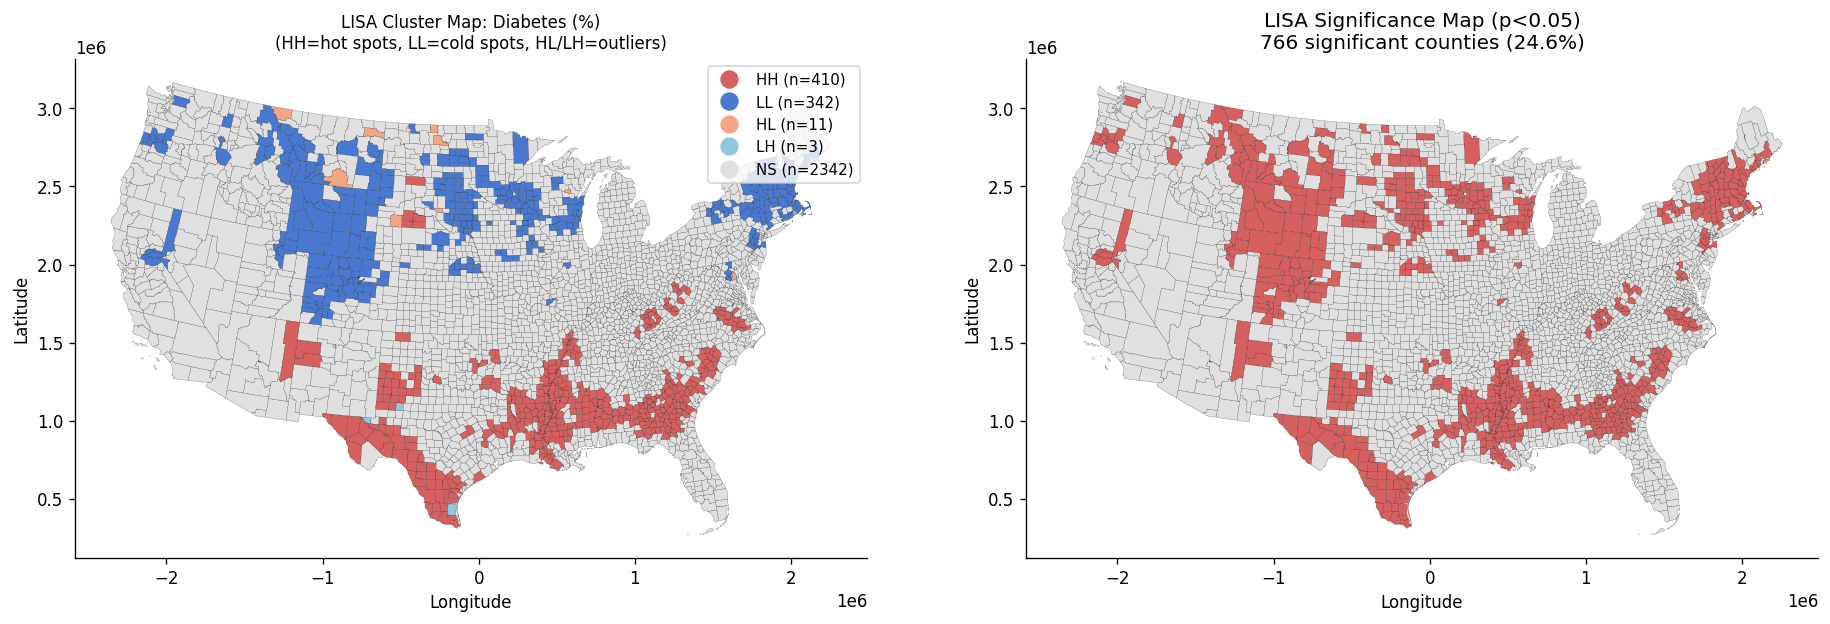

LISA cluster summary (Diabetes):
  HH:  410 counties (13.2%)
  LL:  342 counties (11.0%)
  HL:   11 counties (0.4%)
  LH:    3 counties (0.1%)
  NS: 2342 counties (75.4%)


In [5]:
def local_morans_i(y, W, n_perm=499, seed=42):
    """Compute Local Indicators of Spatial Association (LISA)."""
    n = len(y)
    z = y - y.mean()
    var_z = z.var()
    # Local I_i = z_i * sum_j(w_ij * z_j) / var(z)
    Wz = W @ z
    I_local = z * Wz / var_z
    # Pseudo p-values via conditional permutation
    rng = np.random.default_rng(seed)
    I_perm = np.zeros((n_perm, n))
    for b in range(n_perm):
        z_p = rng.permutation(z)
        Wz_p = W @ z_p
        I_perm[b] = z_p * Wz_p / var_z
    p_values = (np.abs(I_perm) >= np.abs(I_local[np.newaxis,:])).mean(axis=0)
    # Classify quadrants
    z_lag = Wz / z.std()
    z_std = z / z.std()
    quadrant = np.where((z_std>0)&(z_lag>0), "HH",
               np.where((z_std<0)&(z_lag<0), "LL",
               np.where((z_std>0)&(z_lag<0), "HL", "LH")))
    cluster = np.where(p_values<0.05, quadrant, "NS")
    return {"I_local":I_local,"p_values":p_values,"cluster":cluster}

# Use diabetes data instead of CVD
lisa_res_diabetes = local_morans_i(gdf.Diabetes.values, W_queen)
gdf["lisa_cluster_diabetes"] = lisa_res_diabetes["cluster"]
gdf["lisa_i_diabetes"]       = lisa_res_diabetes["I_local"]
gdf["lisa_p_diabetes"]       = lisa_res_diabetes["p_values"]

# Cluster map using GeoPandas built-in plotting
import geopandas as gpd

cluster_colors = {"HH":"#D65F5F","LL":"#4878CF","HL":"#F4A582","LH":"#92C5DE","NS":"#E0E0E0"}
gdf["lisa_color_diabetes"] = gdf["lisa_cluster_diabetes"].map(cluster_colors)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot LISA cluster map for Diabetes
gdf.plot(ax=axes[0], color=gdf["lisa_color_diabetes"], edgecolor="k", linewidth=0.1)
axes[0].set_title("LISA Cluster Map: Diabetes (%)\n(HH=hot spots, LL=cold spots, HL/LH=outliers)", fontsize=10)
axes[0].set_xlabel("Longitude"); axes[0].set_ylabel("Latitude")
for label, color in cluster_colors.items():
    n_cl = (gdf.lisa_cluster_diabetes==label).sum()
    axes[0].plot([],[],"o",color=color,ms=10,label=f"{label} (n={n_cl})")
axes[0].legend(fontsize=9, loc="best")

# Significance map for Diabetes
sig_colors = {True:"#D65F5F", False:"#E0E0E0"}
sig_mask = lisa_res_diabetes["p_values"] < 0.05
gdf["lisa_sig_color_diabetes"] = np.vectorize(sig_colors.get)(sig_mask)
gdf.plot(ax=axes[1], color=gdf["lisa_sig_color_diabetes"], edgecolor="k", linewidth=0.1)
axes[1].set_title(f"LISA Significance Map (p<0.05)\n{sig_mask.sum()} significant counties ({sig_mask.mean()*100:.1f}%)")
axes[1].set_xlabel("Longitude"); axes[1].set_ylabel("Latitude")
plt.tight_layout()
plt.savefig("/tmp/mod07/lisa_cluster_map_diabetes.png", bbox_inches="tight"); plt.show()

# Summary
print("LISA cluster summary (Diabetes):")
for label in ["HH","LL","HL","LH","NS"]:
    n = (gdf.lisa_cluster_diabetes==label).sum()
    print(f"  {label}: {n:4d} counties ({n/len(gdf)*100:.1f}%)")


The Local Indicators of Spatial Association (LISA) cluster map above reveals spatial patterns in county-level CVD mortality rates:
- **HH (High-High):** "Hot spot" counties with high CVD rates surrounded by high-rate neighbors. These are potential priority regions for intervention.
- **LL (Low-Low):** "Cold spot" counties with low rates next to other low-rate counties, indicating healthier spatial clusters.
- **HL (High-Low):** High-rate counties surrounded by low-rate neighbors (potential spatial outliers).
- **LH (Low-High):** Low-rate counties surrounded by high-rate neighbors (also spatial outliers).
- **NS (Not Significant):** Counties where the local Moran's I was not statistically significant (p ≥ 0.05), indicating no strong local clustering.

The left plot shows the spatial position of clusters, colored by type, and the right plot highlights which clusters were statistically significant at p<0.05. 

The summary below counts counties in each category, helping identify the prevalence and potential public health importance of each type of spatial pattern.

## 5. Bivariate Local Moran's I

The **Bivariate Local Moran's I** is a method to analyze whether the value of one variable at a location (e.g., County A's CVD mortality rate) is related to the values of a *different* variable in neighboring locations (such as poverty rate in nearby counties).

**What does the bivariate statistic measure?**
- Are *high* CVD rates in County A surrounded by *high* poverty rates in neighboring counties?
- Or are *low* CVD rates surrounded by *low* poverty nearby?
- Or is there a mismatch between the two variables?

### Steps:

1. **Choose two variables:**
   - **x**: Value at the target location (e.g., CVD deaths in County A)
   - **y**: Value in each neighboring location (e.g., poverty rate in surrounding counties)

2. **Standardize both variables:**
   - Subtract each variable's mean and divide by its standard deviation.
   - This gives both variables a *mean of 0* and *standard deviation of 1*.
   - $$
     z_{x,i} = \frac{x_i - \overline{x}}{s_x}
     $$
   - $$
     z_{y,j} = \frac{y_j - \overline{y}}{s_y}
     $$

3. **For each county $i$, calculate the bivariate Local Moran's I:**
   - $$
     I_i = z_{x,i} \times \left( \sum_j w_{ij} \cdot z_{y,j} \right)
     $$
   - Where:
     - $w_{ij}$ = spatial weight between county $i$ and neighbor $j$ (e.g., 1 if they touch, 0 otherwise).
   - *Translation:* "How much is the CVD rate in county $i$ related to the (weighted) average poverty in its neighbors?"

4. **What does the value mean?**
   - **Large positive $I_i$**:
     - County $i$ has high CVD, surrounded by neighbors with high poverty (*High-High cluster*), or
     - County $i$ has low CVD, surrounded by low poverty neighbors (*Low-Low cluster*).
   - **Large negative $I_i$**:
     - County $i$ is an *outlier*: for example, low CVD in county $i$, but high poverty in neighbors (or vice versa).

5. **Easy analogy:**  
   - Think of checking whether a "bad" heart health spot is located in a "bad" poverty region—or if it stands out as an exception among its neighbors.

> Bivariate Local Moran's I shows whether *the value of one variable* at a location (like heart deaths) is spatially associated with *the value of a different variable* nearby (like poverty). It also reveals *where* these connections or mismatches occur on your map.

('WARNING: ', 1332, ' is an island (no neighbors)')
('WARNING: ', 2088, ' is an island (no neighbors)')


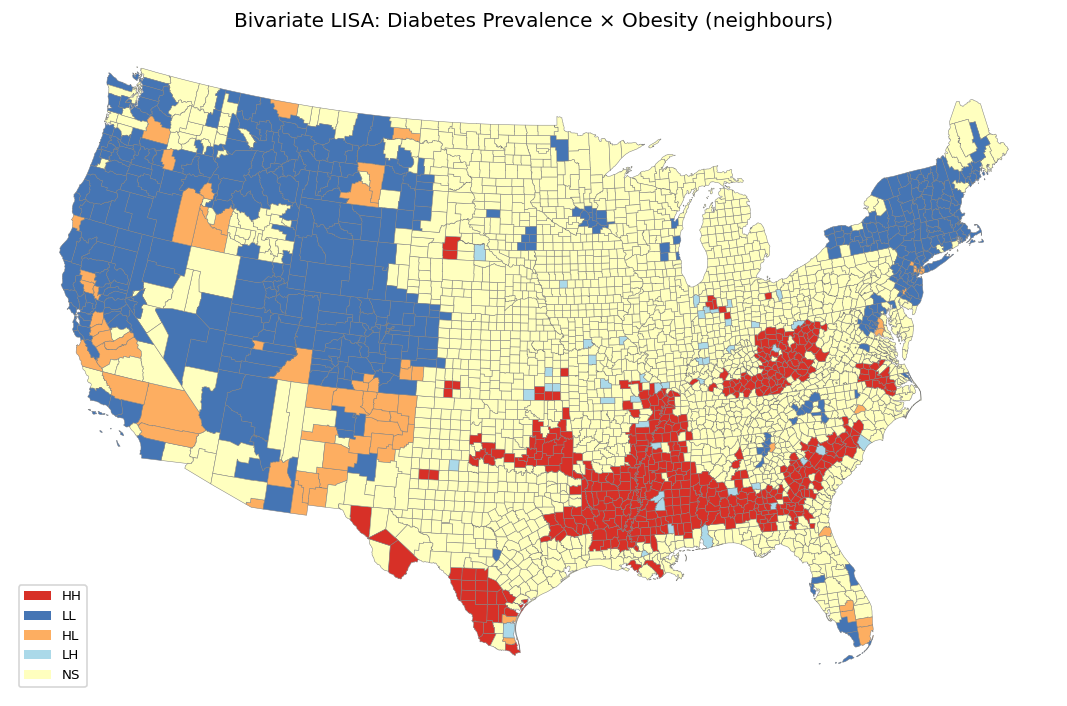

NS    2031
HH     486
LL     474
HL      71
LH      46
Name: count, dtype: int64


In [6]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from libpysal.weights import Queen


W = Queen.from_dataframe(gdf)
W.transform = "r"

from esda.moran import Moran_Local_BV
import numpy as np
from matplotlib.patches import Patch

x = gdf["Diabetes"].astype(float).values
y = gdf["Obesity"].astype(float).values
lm_bv = Moran_Local_BV(x, y, W, permutations=999, seed=42)

sig = lm_bv.p_sim < 0.05
quadrant = np.full(len(gdf), "NS", dtype=object)
q1 = sig & (lm_bv.q == 1); q2 = sig & (lm_bv.q == 2)
q3 = sig & (lm_bv.q == 3); q4 = sig & (lm_bv.q == 4)
quadrant[q1] = "HH"; quadrant[q2] = "LH"
quadrant[q3] = "LL"; quadrant[q4] = "HL"
gdf["bivar_cluster"] = quadrant

bv_colors = {"HH": "#d73027", "LL": "#4575b4", "HL": "#fdae61", "LH": "#abd9e9", "NS": "#ffffbf"}
fig, ax = plt.subplots(figsize=(9, 8))
gdf.plot(color=[bv_colors[c] for c in gdf["bivar_cluster"]], linewidth=0.3,
         edgecolor="0.5", ax=ax)
ax.legend(handles=[Patch(facecolor=c, label=l) for l, c in bv_colors.items()],
          loc="lower left", fontsize=8)
ax.set_axis_off()
ax.set_title("Bivariate LISA: Diabetes Prevalence × Obesity (neighbours)")
plt.tight_layout(); plt.show()
print(pd.Series(quadrant).value_counts())


The bivariate Local Moran's I analysis above identifies clusters and spatial outliers where diabetes rates in a county are associated with obesity rates in neighboring counties. The map colors each county by its cluster type:

- **HH (High-High):** Counties with high diabetes rates surrounded by neighbors with high obesity rates. These are spatial "hot spots" for both variables.
- **LL (Low-Low):** Counties with low diabetes rates surrounded by low obesity neighbors — "cold spots."
- **HL (High-Low):** Counties with high diabetes rates but surrounded by neighbors with low obesity rates — spatial outliers.
- **LH (Low-High):** Counties with low diabetes but surrounded by neighbors with high obesity — the reverse type of outlier.
- **NS (Not Significant):** No significant spatial association detected.

By visualizing these clusters, we can spot geographic areas where diabetes and obesity patterns reinforce each other, as well as regions that stand out as mismatches - helping public health analysts target interventions or further investigate unusual regions. The legend and printed counts show how many counties fall into each type.

## 5. Bivariate Local Moran's I

# ### Bivariate Local Moran's I (for Dummies)

# The **Bivariate Local Moran's I** is a way to see if a value at a location (for example, County A's CVD mortality rate)
# is similar to *a different variable* (say, poverty rate) in its neighboring locations. It's like asking:
# 
# > "Are high CVD rates in one county surrounded by high poverty rates in neighboring counties?"
# 
# **How does it work (dummy math version)?**
# 
# 1. **Pick two variables:**  
#    - Variable 1 (x): CVD mortality rate in each county.
#    - Variable 2 (y): Poverty rate in each (neighbor) county.
# 
# 2. **Standardize** each variable (subtract the mean, divide by standard deviation) to make numbers comparable.
# 
# 3. **For each county (i), calculate:**  
#    - \( I_i = x_i \times \text{[average of } y_j \text{ in neighboring counties j]} \)
# 
#    In reality, it includes "weights" to count closer neighbors more, but the main idea is:
#    - Big and positive \( I_i \): County i has high CVD *and* is surrounded by high poverty neighbors.
#    - Big and negative \( I_i \): County i has high CVD *but* is surrounded by low poverty neighbors.
# 
# 4. **Interpretation:**  
#    - High positive values = "high-high" clusters (link between x and y around that location).
#    - High negative values = "outliers" (a mismatch between x at i and y in neighbors).
# 
# **In short:**  
# Bivariate Local Moran's I asks whether patterns in one variable at a location match up with 
# patterns in a different variable nearby — *and shows you where these relationships are strong on the map*.

## 6. Getis-Ord G* Hot Spot Analysis

The **Getis-Ord G*** statistic is a way to find "hot spots" (areas surrounded by other high-value areas) and "cold spots" (areas surrounded by other low-value areas) on your map.

### How does it work?

Imagine you want to know if a county with high heart disease deaths is part of a "hot spot" (cluster of high deaths) or just a single bad spot in a sea of better neighbors.

**Step-by-step:**

1. **Pick your variable:**  
   - For example, death rate in each county.

2. **For each county (i):**
   - Add up the rates in its "neighborhood": itself **plus** all its neighbors.
   - (This is different from Moran's I, which skips itself!)
   - If you like formulas:  
     - "Sum up the values for county *i* and all its connected neighbors."

3. **Compare this local sum to the overall average:**  
   - If the total for that area is **much higher than average**, it's a **hot spot**.
   - If it's **much lower**, it's a **cold spot**.

4. **The actual G\* statistic:**  
   - It tells you (in "standard deviation units") how far above or below average this area's sum is compared to what you'd expect just by luck.
   - Big positive G* = "hot spot" (lots of high values together).
   - Big negative G* = "cold spot" (lots of low values together).

**Key idea:**  
- G* finds places where clusters of high or low values occur more often than you'd expect just by chance.

**Example:**  
> "If my county plus my neighbors have much higher death rates *together* than most, I show up as a hot spot."

In sum:  
- **Getis-Ord G\*** is a "hot/cold spot finder" that looks for unusually high/low clusters by adding up values locally and comparing to the big picture average.



**Getis-Ord G* Hot Spot Analysis vs. LISA (Local Moran's I):**

Imagine you’re looking for “interesting” areas on a map of counties — either *clusters* of high/low values, or weird *outliers*.

- **What are they trying to find?**
  - **LISA (Local Moran’s I):** Looks for spots where a place is “like its neighbors” (e.g., a high value surrounded by other highs — or a low among lows) *and* places that are “unlike their neighbors” (a high value surrounded by lows, or vice versa).
  - **Getis-Ord G\* (G-star):** Pinpoints “hot spots” (lots of high values neighboring each other) or “cold spots” (lots of low values clumped together) — but not outliers.

- **Who’s in your neighborhood?**
  - **LISA:** Only includes the *neighboring* counties. It *ignores itself* — like checking what’s around you, but not counting your own score.
  - **Getis-Ord G\*:** Includes *itself and all its neighbors* — so you count the county *plus* everyone it touches when deciding if you’re in a hot/cold spot.

- **What does the math actually ask?**
  - **LISA:** “Is my county’s value surprisingly high/low *compared to* my neighbors?” It answers: “Am I a part of a *cluster*, or am I an *outlier*?”
  - **Getis-Ord G\*:** “Do my county and its neighbors *together* have a sum much bigger/smaller than average?” If yes: it’s a “hot” or “cold” spot! Outliers (a high surrounded by lows) don't get flagged.

- **How do you know if it’s real?**
  - Both use “what if things were random?” logic (statistical tests or permutations) to see if the result is special, then give you a p-value.

- **Why use one or the other?**
  - **LISA:** When you want to map out where there are interesting *local patterns*: clusters *and* outliers.
  - **Getis-Ord G\*:** When you want to quickly flag “hot spots” or “cold spots" for action — great for targeting resources, like finding concentrated areas with high health risk.

**In summary (really simple):**
- LISA: “Is my value weird or part of a group?”
- G\*: “Are me + my neighbors a big pile of high (hot spot) or low (cold spot)?”

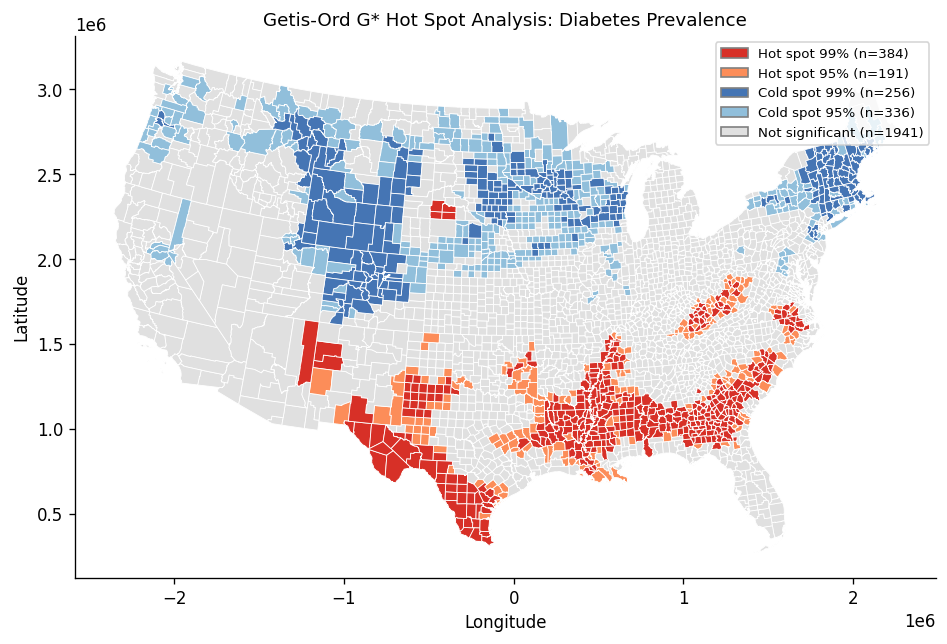

In [7]:
def getis_ord_gstar(y, W_binary, W_row_std=None):
    """
    Getis-Ord G* statistic for hot spot analysis.
    G*_i = (sum_j w_ij*x_j - X_bar*sum_j w_ij) /
            S * sqrt((n*sum_j w_ij^2 - (sum_j w_ij)^2) / (n-1))
    """
    n = len(y)
    X_bar = y.mean()
    S = y.std()
    G_star = np.zeros(n)
    for i in range(n):
        w_i = W_binary[i]
        sum_w = w_i.sum()
        sum_wx = (w_i * y).sum()
        num = sum_wx - X_bar * sum_w
        sum_w2 = (w_i**2).sum()
        denom_sq = sum_w2 - sum_w**2/n
        if denom_sq > 0 and S > 0:
            denom = S * np.sqrt((n*sum_w2 - sum_w**2) / (n-1))
            G_star[i] = num / denom if denom > 0 else 0
        else:
            G_star[i] = 0
    return G_star

# Build binary (non-standardised) queen weights
W_binary = (W_queen > 0).astype(float)
np.fill_diagonal(W_binary, 1)  # G* includes self

# --- Use Diabetes data from gdf ---
g_star = getis_ord_gstar(gdf.Diabetes.values, W_binary)
from scipy.stats import norm as sp_norm
p_gstar = 2 * sp_norm.sf(np.abs(g_star))

gdf["g_star"]   = g_star
gdf["g_star_p"] = p_gstar

hotspot_class = np.where((g_star > 2.58) & (p_gstar<0.01), "Hot spot 99%",
                np.where((g_star > 1.96) & (p_gstar<0.05), "Hot spot 95%",
                np.where((g_star < -2.58) & (p_gstar<0.01), "Cold spot 99%",
                np.where((g_star < -1.96) & (p_gstar<0.05), "Cold spot 95%", "Not significant"))))

hs_colors = {"Hot spot 99%":"#D73027","Hot spot 95%":"#FC8D59",
             "Cold spot 99%":"#4575B4","Cold spot 95%":"#91BFDB","Not significant":"#E0E0E0"}
gdf["hotspot_class"] = hotspot_class
gdf["hotspot_color"] = [hs_colors[h] for h in hotspot_class]

fig, ax = plt.subplots(figsize=(8, 6))
gdf.plot(ax=ax, color=gdf["hotspot_color"], edgecolor="white", linewidth=0.5)
ax.set_title("Getis-Ord G* Hot Spot Analysis: Diabetes Prevalence", fontsize=11)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, edgecolor='gray', label=f"{label} (n={np.sum(hotspot_class==label)})") for label, color in hs_colors.items()]
ax.legend(handles=legend_elements, fontsize=8)
plt.tight_layout()
plt.savefig("/tmp/mod07/getis_ord_gstar_diabetes_map.png", bbox_inches="tight"); plt.show()


## 67 Knowledge Check

1. Global Moran's I = 0.42 (p<0.001). Does this statistic inform us about the *location* of spatial clusters? Explain.
2. A LISA (Local Indicators of Spatial Association) map identifies an HL (High-Low) outlier—a county with high CVD surrounded by counties with low CVD. List three plausible reasons for such a spatial outlier:
   - (a) __
   - (b) __
   - (c) __
3. If you switched from queen contiguity weights to k-nearest neighbor (k=8) spatial weights, how would you expect the calculated Moran's I to change? Why?
4. When interpreting LISA p-values, why is it important to be cautious given that 200 local tests are conducted simultaneously?
5. Calculate Moran's I for the *residuals* from an OLS regression of CVD on poverty. What does the result tell you about spatial dependence after adjustment?


In [8]:
# Exercise 5 — Moran's I on OLS residuals (updated variable names and code)
from sklearn.linear_model import LinearRegression

# Use updated variable names consistent with diabetes example
print(f"gdf columns: {list(gdf.columns)}")  # Debugging aid

# Ensure the columns exist and are named correctly (case/check)
expected_vars = ["Obesity", "smr" , "Uninsured"]
missing = [col for col in expected_vars if col not in gdf.columns]
if missing:
    raise KeyError(f"Columns not found in gdf: {missing}. Available columns: {list(gdf.columns)}")

X_vars = expected_vars   # Predictor variables (from above check)
y_var = "Diabetes"       # Outcome variable

# Fit OLS regression model
ols_model = LinearRegression()
ols_model.fit(gdf[X_vars], gdf[y_var])

# Calculate residuals
diabetes_pred_ols = ols_model.predict(gdf[X_vars])
diabetes_residuals_ols = gdf[y_var] - diabetes_pred_ols

# Moran's I on OLS residuals
morans_ols = morans_i(diabetes_residuals_ols.values, W_queen, n_perm=499)

# (Assume morans_i was run previously on raw Diabetes for res_diabetes)
print(f"Moran's I on Diabetes rate           : {res_diabetes['I']:.4f} (p={res_diabetes['p_value']:.4f})")
print(f"Moran's I on OLS residuals           : {morans_ols['I']:.4f} (p={morans_ols['p_value']:.4f})")
print()
if morans_ols["p_value"] < 0.05:
    print("Significant residual spatial autocorrelation -> OLS is biased!")
    print("Need spatial regression models (spatial lag or spatial error).")
else:
    print("Residual spatial autocorrelation removed by covariate adjustment.")


gdf columns: ['FIPS', 'x', 'y', 'REGION_ID', 'DIVISION_I', 'STATE_ID', 'COUNTY_ID', 'REGION', 'DIVISION', 'STATE', 'COUNTY', 'geometry', 'county_id', 'fips', 'county', 'state_abbr', 'state_name', 'lon', 'lat', 'x_m', 'y_m', 'Diabetes', 'Population 65+', 'pct_exercise', 'Obesity', 'Food env. index', 'PCP', 'rural_pop', 'Unemployed', 'Uninsured', 'smr', 'lisa_cluster_diabetes', 'lisa_i_diabetes', 'lisa_p_diabetes', 'lisa_color_diabetes', 'lisa_sig_color_diabetes', 'bivar_cluster', 'g_star', 'g_star_p', 'hotspot_class', 'hotspot_color']


Moran's I on Diabetes rate           : 0.6650 (p=0.0000)
Moran's I on OLS residuals           : 0.2659 (p=0.0000)

Significant residual spatial autocorrelation -> OLS is biased!
Need spatial regression models (spatial lag or spatial error).


***
**Next → NB-03: Spatial Regression — Lag, Error & GWR**
